# Fase 4 — Modelado predictivo de RUL
### NASA C-MAPSS FD001 — sobre el conjunto canónico de Fase 2

**Punto de partida.** Consume `train/test_FD001_features_112.parquet`
(Fase 2, conjunto canónico: `windows=[15,30]`, mean/std/slope + delta
acumulado). Es, feature a feature, el mismo conjunto que reconstruían
ad hoc `fase5_evaluacion.py` y `fase7_mejoras.py` para poder usar los
modelos ya guardados en `models/`.

**Decisión de escalado que difiere de la Fase 4 original documentada.**
La Fase 4 original solo aplicaba `StandardScaler` a Ridge, dejando sin
escalar a los modelos de árbol. Pero `models/final_scaler.pkl` —el que
ya usaban `fase5_evaluacion.py`/`fase7_mejoras.py` para cargar los
modelos guardados— es un `StandardScaler` sobre las 112 features
aplicado a **los 4 modelos por igual**. Un reescalado monótono por
columna no cambia las predicciones de un árbol de decisión (los splits
comparan umbrales; el orden relativo de los valores no cambia), así que
para RandomForest/XGBoost/LightGBM es un no-op funcional — pero hay que
reproducirlo igual: si el modelo se entrenó con features escaladas,
alimentarlo sin escalar en inferencia sería incorrecto (los splits
están en "unidades escaladas").

**Referencias:**
- Li, X., Ding, Q., & Sun, J.-Q. (2018). Reliability Engineering &
  System Safety, 172, 1-11. — validación agrupada por motor.
- Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.
- Chen, T., & Guestrin, C. (2016). XGBoost. KDD 2016.
- Ke, G. et al. (2017). LightGBM. NeurIPS 30.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of
  Statistical Learning (2nd ed.). Springer.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase4_modelado as f4
import fase2_feature_engineering as f2
import fase0_preprocesado as f0


In [2]:
import inspect

def show_source(func, note=None):
    """Código fuente REAL de una función importada, con su ubicación
    exacta — visibilidad total sin salir del notebook, sin duplicar la
    única implementación que vive en el .py."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice — ubicación exacta
impresa por `show_source()` justo antes de su primer uso):

| Función | Para qué |
|---|---|
| `load_features_112` | Carga el conjunto canónico de Fase 2, descarta NaN, separa test (último ciclo) |
| `build_models` | Los 4 modelos con los hiperparámetros documentados en el README |
| `cross_validate_models` | GroupKFold(k=5) + StandardScaler por fold, aplicado a los 4 modelos |
| `train_final_models` | Reentrena en 100% train, guarda scaler + modelos en `models/` |
| `compare_with_readme` | Compara este run contra los números ya publicados |
| `load_features_112_ext` | Igual que `load_features_112`, añade el target de clasificación `early_failure` |
| `build_classification_models` | Variante de clasificación de los 4 modelos (LogisticRegression + 3 Classifier), class_weight balanceado |
| `cross_validate_classifiers` | GroupKFold(k=5) con métricas F1/Recall/Precision/ROC-AUC |
| `train_final_classifiers` | Reentrena en 100% train, guarda `*_classifier_fd001.pkl` |


## 1. Carga del conjunto canónico (Fase 2)

In [3]:
show_source(f4.load_features_112)

📍 load_features_112  —  scripts\fase4_modelado.py:119
------------------------------------------------------------------------------
def load_features_112():
    """
    Carga train/test_FD001_features_112.parquet (Fase 2, conjunto
    canónico) y devuelve (X_train, y_train, groups, X_test, y_test,
    feat_cols) — firma ORIGINAL, sin tocar, porque fase5_evaluacion.py
    y fase7_mejoras.py ya la desempaquetan así. Delega en
    load_features_112_ext() (extensión de clasificación) y descarta los
    dos targets adicionales para mantener el contrato exacto.
    """
    (X_train, y_train, _y_train_clf, groups,
     X_test, y_test, _y_test_clf, feat_cols) = load_features_112_ext()
    return X_train, y_train, groups, X_test, y_test, feat_cols



In [4]:
X_train, y_train, groups, X_test, y_test, feat_cols = f4.load_features_112()
assert len(feat_cols) == 112
print(f"\n✓ {len(feat_cols)} features, {X_train.shape[0]} filas de train, {X_test.shape[0]} de test.")


  Train: (17731, 112)  (de 20631 filas, 2900 descartadas por NaN)
  Test (último ciclo/motor): 100 muestras
  Target train — μ=80.6, σ=41.8
  Target clasificación train — early_failure=1: 3100/17731 (17.5%)

✓ 112 features, 17731 filas de train, 100 de test.


## 2. Modelos y validación cruzada GroupKFold

**Base teórica — por qué GroupKFold y no KFold estándar.** Cada motor
es una serie temporal completa; sus ciclos consecutivos comparten
features de ventana deslizante muy correlacionadas entre sí. Un
`KFold` aleatorio pondría ciclos del mismo motor en train y en
validación simultáneamente — el modelo "vería" (indirectamente, vía
features solapadas) parte de la trayectoria que se supone debe
predecir, dando un RMSE artificialmente optimista (Li et al., 2018).
`GroupKFold(k=5, groups=engine_id)` garantiza que los motores de
validación son completamente distintos de los de entrenamiento en cada
fold.


In [5]:
show_source(f4.build_models)

📍 build_models  —  scripts\fase4_modelado.py:187
------------------------------------------------------------------------------
def build_models():
    """
    Hiperparámetros documentados en el README original del proyecto —
    se mantienen sin cambios para que esta Fase 4 sea comparable con
    los resultados ya publicados:

    Ridge (α=10): regularización L2 de orden de magnitud estándar para
      features normalizadas (Hastie et al., 2009).
    RandomForest (n=150, max_depth=15, min_samples_leaf=4,
      max_features=0.33): compromiso velocidad/varianza para CV×5
      (Breiman, 2001).
    XGBoost (lr=0.05, n=300, max_depth=6, subsample/colsample=0.8):
      parámetros de referencia para datos tabulares (Chen & Guestrin,
      2016), con regularización estocástica.
    LightGBM (lr=0.05, n=300, num_leaves=63 ≈ 2^6-1, equivalente
      aproximado a max_depth=6 con crecimiento leaf-wise; Ke et al.,
      2017).
    """
    return {
        "Ridge": Ridge(alpha=10, fit_intercept=Tr

In [6]:
show_source(f4.cross_validate_models)

📍 cross_validate_models  —  scripts\fase4_modelado.py:230
------------------------------------------------------------------------------
def cross_validate_models(X, y, groups, models):
    """
    GroupKFold(k=5): los motores del fold de validación son
    completamente distintos de los de entrenamiento — replica el
    escenario real (predecir RUL de motores no vistos).

    El StandardScaler se ajusta SOLO sobre el fold de train en cada
    iteración (nunca sobre el fold de validación) y se aplica a los 4
    modelos por igual, para que la comparación entre modelos no se vea
    afectada por si alguno recibe features en una escala distinta.
    """
    gkf = GroupKFold(n_splits=N_FOLDS)
    results = {name: {"rmse": [], "mae": [], "r2": [], "preds": [], "trues": []} for name in models}

    print(f"\n  GroupKFold CV (k={N_FOLDS}) — {len(np.unique(groups))} motores")
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_val = X[tr_idx], X[val_idx]
   

In [7]:
models_cv = f4.build_models()
cv_results = f4.cross_validate_models(X_train, y_train, groups, models_cv)

cv_summary = pd.DataFrame({
    name: {"CV_RMSE_mean": np.mean(r["rmse"]), "CV_RMSE_std": np.std(r["rmse"]),
           "CV_MAE_mean": np.mean(r["mae"]), "CV_R2_mean": np.mean(r["r2"])}
    for name, r in cv_results.items()
}).T
cv_summary



  GroupKFold CV (k=5) — 100 motores


  Fold 1: Ridge=17.91  RandomForest=14.17  XGBoost=14.09  LightGBM=14.15


  Fold 2: Ridge=14.83  RandomForest=13.11  XGBoost=12.68  LightGBM=12.77


  Fold 3: Ridge=15.36  RandomForest=12.12  XGBoost=11.72  LightGBM=11.84


  Fold 4: Ridge=15.66  RandomForest=13.26  XGBoost=12.87  LightGBM=13.05


  Fold 5: Ridge=18.21  RandomForest=11.71  XGBoost=12.04  LightGBM=11.88


,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean
Ridge,16.392139,1.390347,12.986939,0.845121
RandomForest,12.874329,0.872309,9.578671,0.904707
XGBoost,12.680705,0.819881,9.226482,0.907591
LightGBM,12.737068,0.854230,9.198147,0.906738


## 3. Entrenamiento final y evaluación en test oficial

Se reentrena cada modelo sobre el 100% de train (con el scaler ajustado
también sobre el 100% de train, guardado en `models/final_scaler.pkl`)
y se evalúa sobre el test oficial: el último ciclo observado de cada
uno de los 100 motores de test, con su RUL verdadero.


In [8]:
show_source(f4.train_final_models)

📍 train_final_models  —  scripts\fase4_modelado.py:271
------------------------------------------------------------------------------
def train_final_models(X_train, y_train, X_test, y_test, models):
    """
    Reentrena cada modelo sobre el 100% de train (con el StandardScaler
    ajustado también sobre el 100% de train) y evalúa en el test
    oficial. Guarda el scaler y cada modelo en models/ — son los
    mismos artefactos que ya consumían fase5_evaluacion.py y
    fase7_mejoras.py.
    """
    scaler = StandardScaler().fit(X_train)
    joblib.dump(scaler, f"{MODEL_DIR}/final_scaler.pkl")

    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    test_results = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        preds = np.clip(model.predict(X_test_s), 0, RUL_CAP)
        test_results[name] = {
            "rmse": np.sqrt(mean_squared_error(y_test, preds)),
            "mae": mean_absolute_error(y_test, preds),
    

In [9]:
models_final = f4.build_models()
test_results = f4.train_final_models(X_train, y_train, X_test, y_test, models_final)

test_summary = pd.DataFrame(test_results).T
test_summary


,rmse,mae,r2,preds
Ridge,14.928788,11.661768,0.861216,"[108.47826, 122.00285, 125.0, 118.04213, 115.7..."
RandomForest,11.042715,8.138369,0.924065,"[118.01136852986957, 117.82862007456507, 119.3..."
XGBoost,11.317602,8.187157,0.920237,"[116.6903, 125.0, 120.89708, 122.482, 118.8716..."
LightGBM,12.054426,8.546759,0.909514,"[114.31723574339237, 121.89487438932036, 121.4..."


### Figuras oficiales (CV boxplot, predicho vs. real, residuos, evaluación de test)

Estas 4 figuras siguen exactamente el mismo contenido que documentaba
el README original (`f4_01`-`f4_04`), regeneradas aquí con el modelo
de este entorno.

📍 plot_cv_comparison  —  scripts\fase4_modelado.py:421
------------------------------------------------------------------------------
def plot_cv_comparison(cv_results, save_path=None):
    """f4_01 — RMSE/MAE/R² por fold (boxplot + media) para los 4 modelos."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    names = list(cv_results.keys())
    colors = [MODEL_COLORS[n] for n in names]
    for ax, metric, mlabel in zip(axes, ["rmse", "mae", "r2"],
                                  ["RMSE (ciclos)", "MAE (ciclos)", "R²"]):
        vals = [cv_results[n][metric] for n in names]
        bp = ax.boxplot(vals, patch_artist=True, widths=0.5,
                        medianprops=dict(color="black", linewidth=2))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color); patch.set_alpha(0.75)
        for i, (v, col) in enumerate(zip(vals, colors)):
            ax.scatter(np.random.normal(i + 1, 0.05, len(v)), v, color=col,
                      s=40, zo

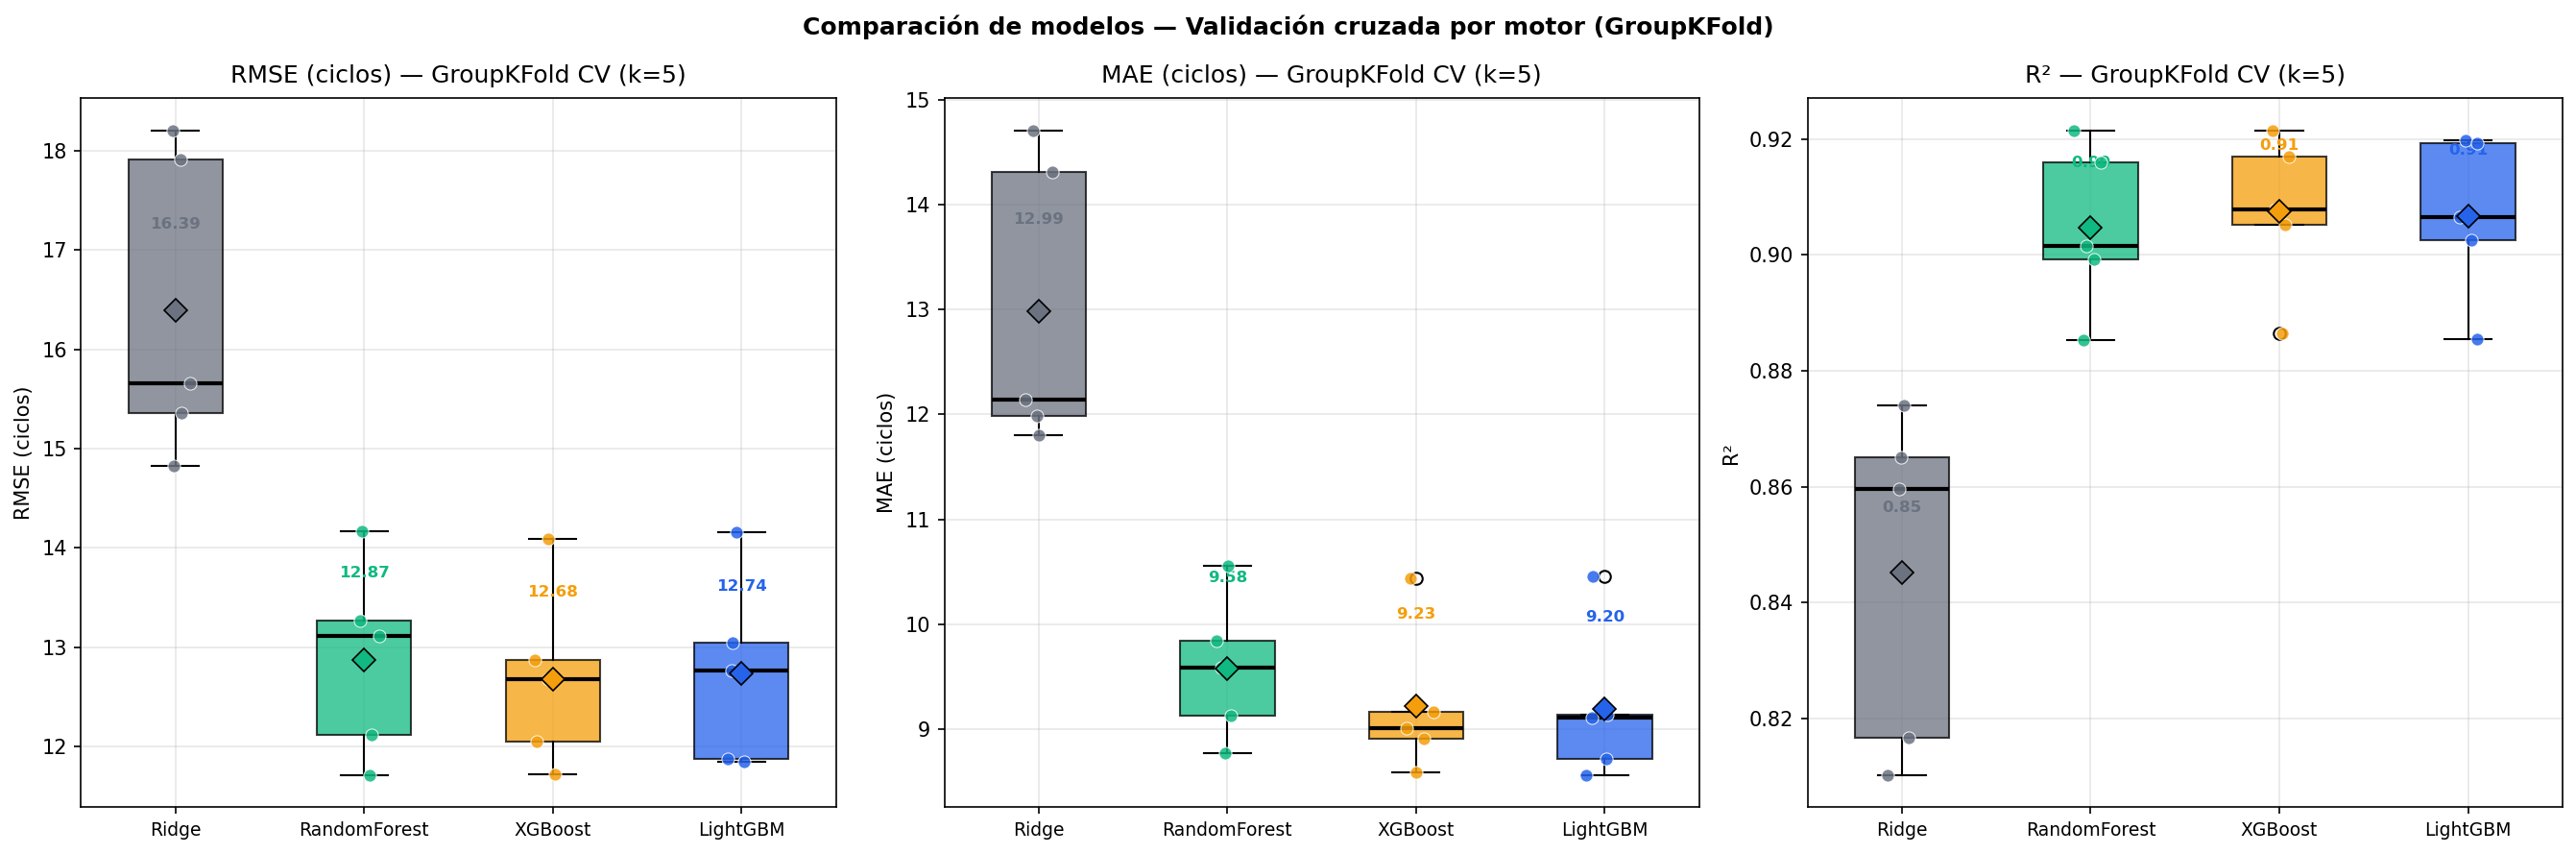

In [10]:
show_source(f4.plot_cv_comparison)
f4.plot_cv_comparison(cv_results, save_path=f"{f4.FIG_DIR}/f4_01_cv_rmse_comparison.png")
display(Image(filename=f"{f4.FIG_DIR}/f4_01_cv_rmse_comparison.png"))

📍 plot_pred_vs_actual  —  scripts\fase4_modelado.py:452
------------------------------------------------------------------------------
def plot_pred_vs_actual(cv_results, save_path=None):
    """f4_02 — Predicho vs. real, todos los folds de CV agregados."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, (name, res) in zip(axes.flatten(), cv_results.items()):
        preds, trues = np.array(res["preds"]), np.array(res["trues"])
        rmse, r2 = np.mean(res["rmse"]), np.mean(res["r2"])
        hb = ax.hexbin(trues, preds, gridsize=40, cmap="Blues", mincnt=1, linewidths=0.2)
        plt.colorbar(hb, ax=ax, label="N.º ciclos")
        lim = (0, RUL_CAP)
        ax.plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
        ax.fill_between(lim, [lim[0]-20, lim[1]-20], [lim[0]+20, lim[1]+20],
                        color="#EF4444", alpha=0.08, label="±20 ciclos")
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("RUL real"); ax.set_ylabel("RU

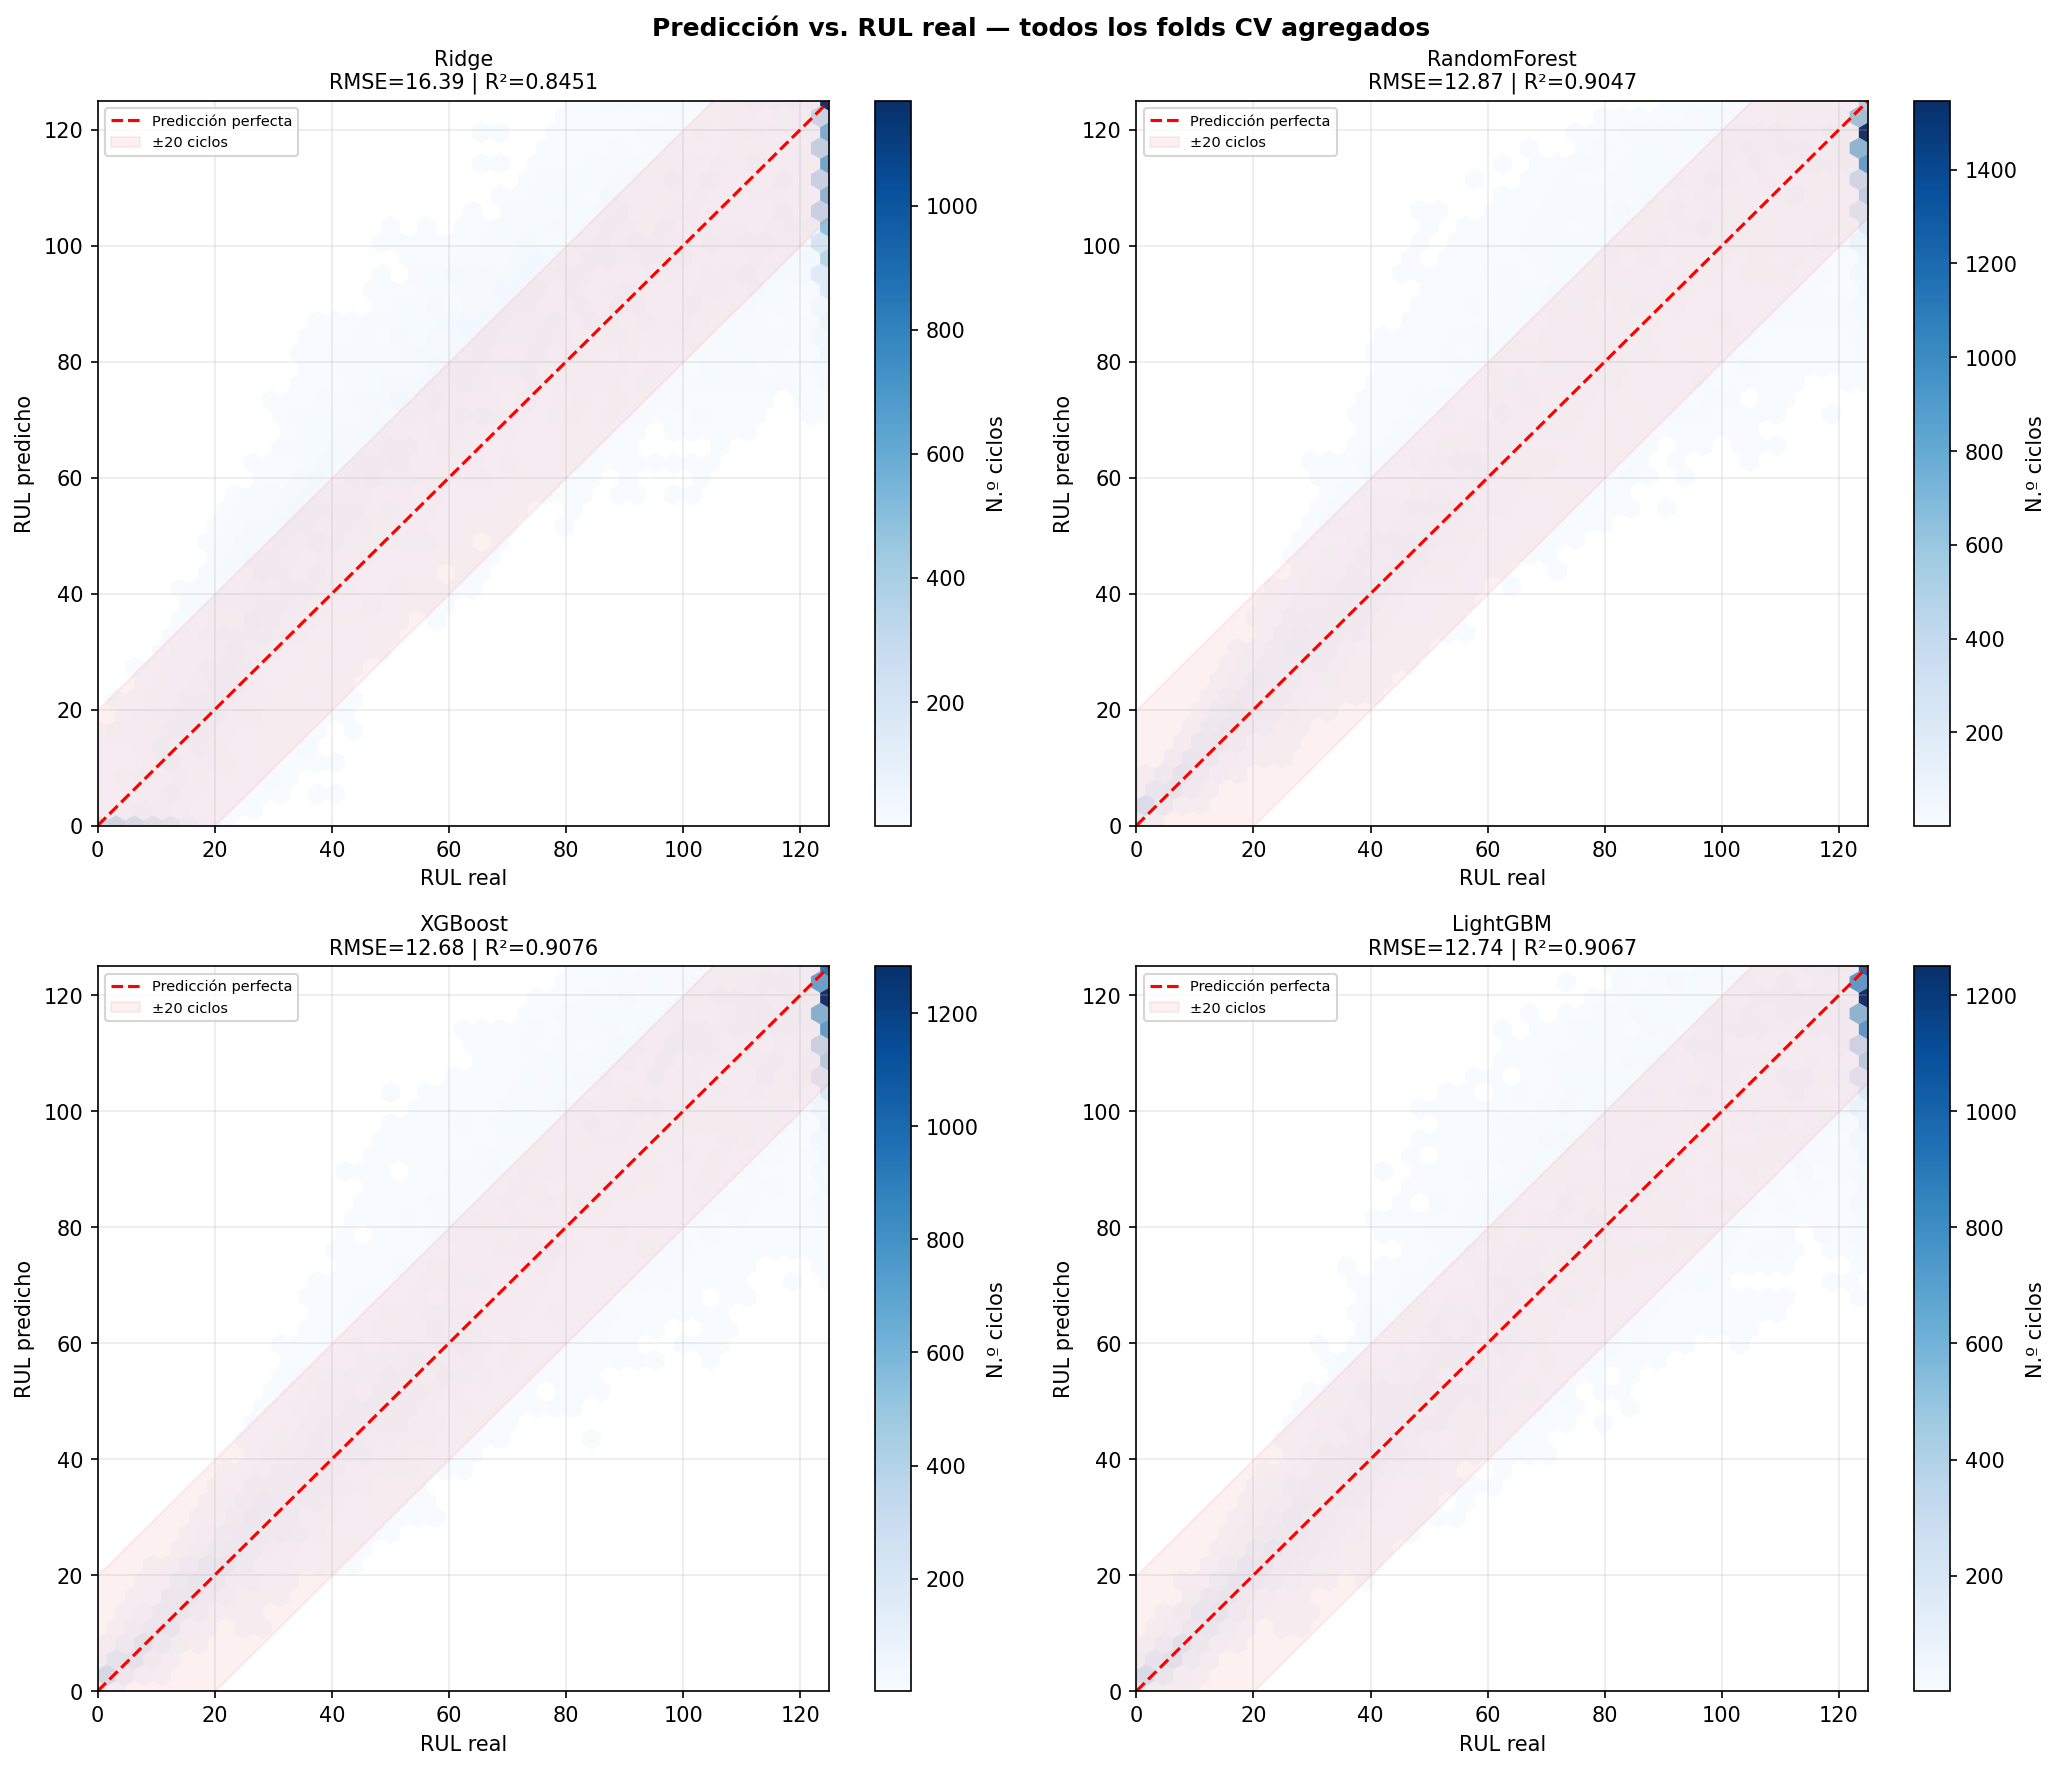

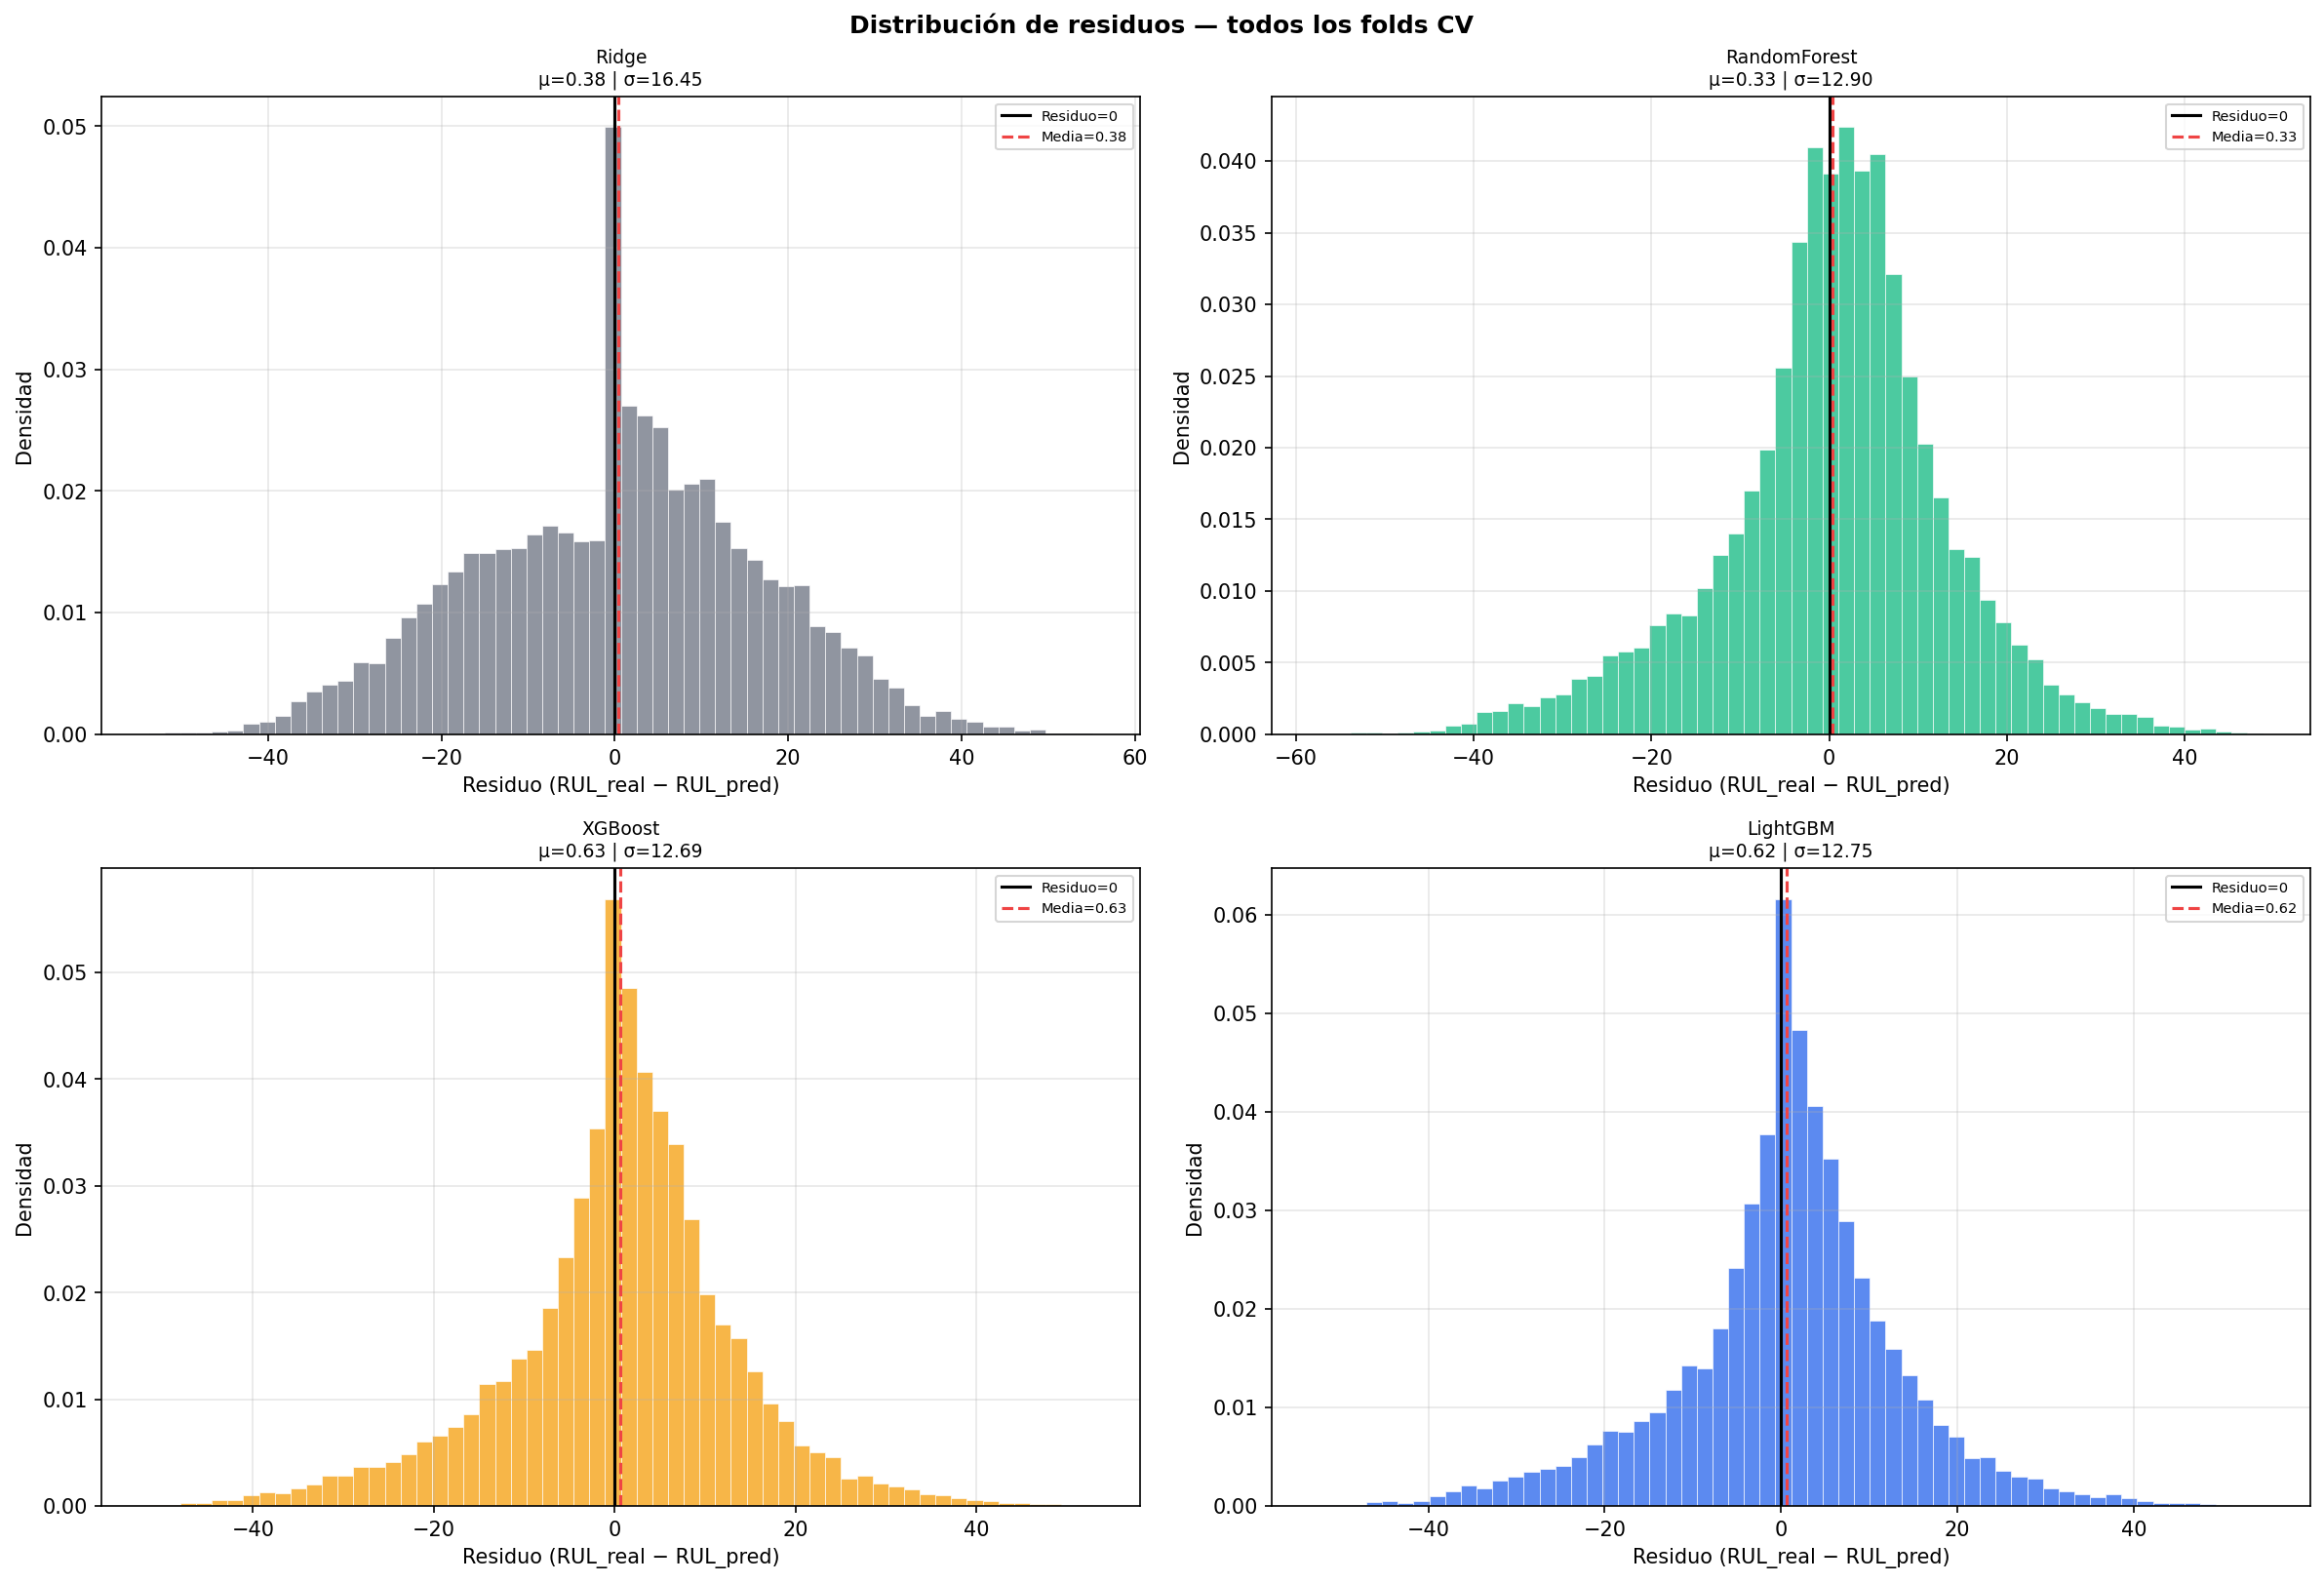

In [11]:
show_source(f4.plot_pred_vs_actual)
show_source(f4.plot_residual_analysis)
f4.plot_pred_vs_actual(cv_results, save_path=f"{f4.FIG_DIR}/f4_02_predicted_vs_actual.png")
f4.plot_residual_analysis(cv_results, save_path=f"{f4.FIG_DIR}/f4_03_residual_analysis.png")
display(Image(filename=f"{f4.FIG_DIR}/f4_02_predicted_vs_actual.png"))
display(Image(filename=f"{f4.FIG_DIR}/f4_03_residual_analysis.png"))

📍 plot_test_evaluation  —  scripts\fase4_modelado.py:497
------------------------------------------------------------------------------
def plot_test_evaluation(test_results, y_test, save_path=None):
    """f4_04 — RMSE/MAE/tabla/mejor modelo sobre el test oficial (100 motores)."""
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
    names = list(test_results.keys())
    colors = [MODEL_COLORS[n] for n in names]

    ax0 = fig.add_subplot(gs[0, 0])
    rmse_vals = [test_results[n]["rmse"] for n in names]
    bars = ax0.bar(names, rmse_vals, color=colors, alpha=0.80, edgecolor="white")
    for bar, v in zip(bars, rmse_vals):
        ax0.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.2f}", ha="center", fontweight="bold")
    ax0.set_ylabel("RMSE (ciclos)"); ax0.set_title("RMSE — Test set oficial"); ax0.grid(alpha=0.35, axis="y")

    ax1 = fig.add_subplot(gs[0, 1])
    mae_vals = [test_results[n]["mae"] for n in names]
    bars = ax1

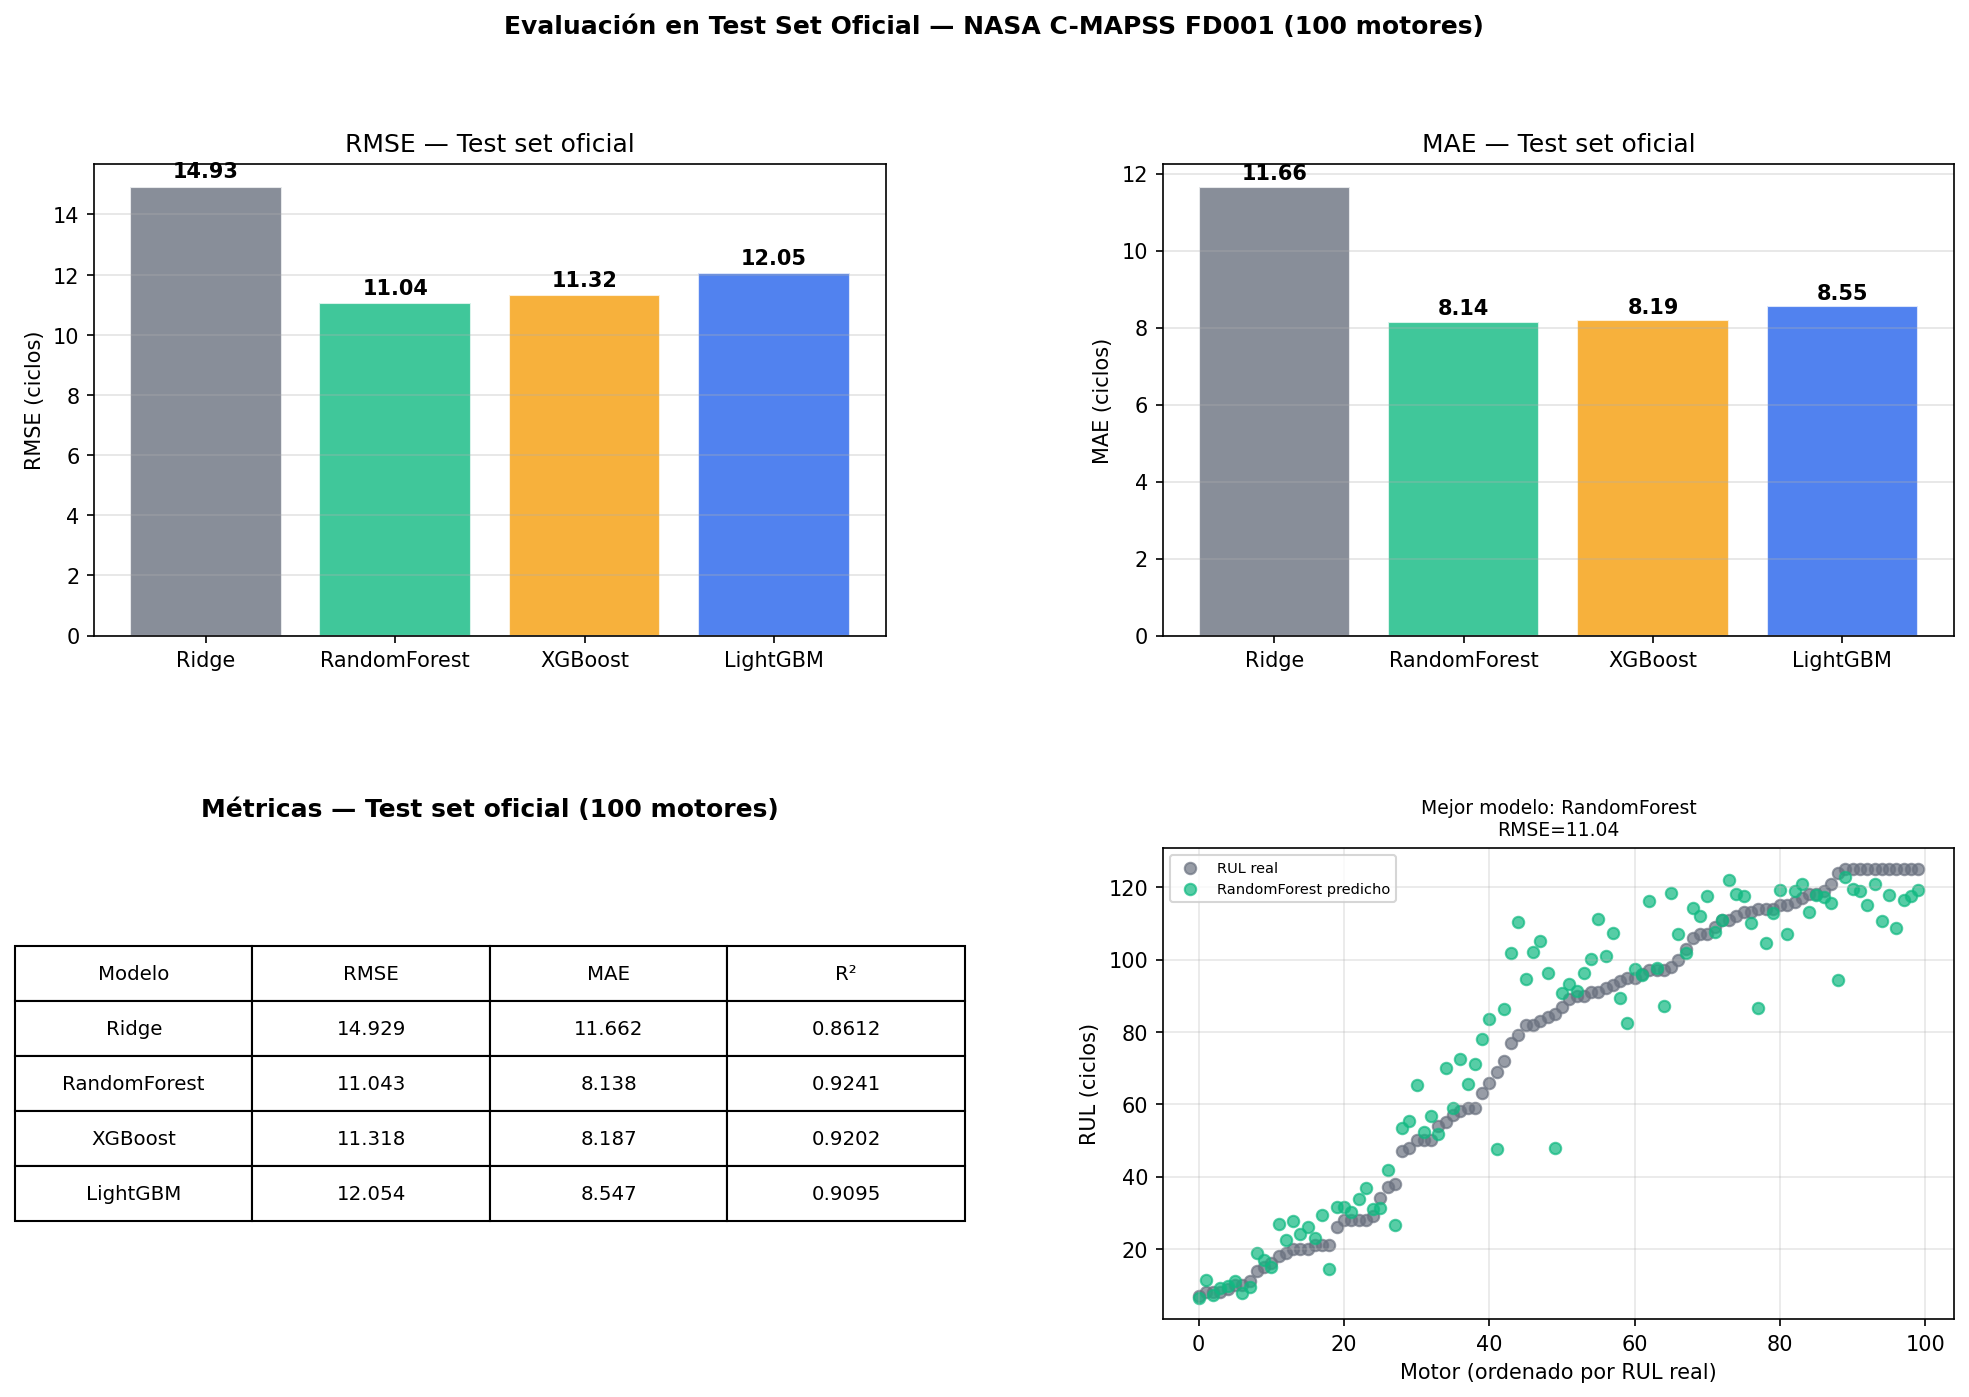

In [12]:
show_source(f4.plot_test_evaluation)
f4.plot_test_evaluation(test_results, y_test, save_path=f"{f4.FIG_DIR}/f4_04_test_set_evaluation.png")
display(Image(filename=f"{f4.FIG_DIR}/f4_04_test_set_evaluation.png"))

## 4. Comparación con el README publicado

**Esto es una verificación empírica, no una suposición.** El objetivo
de reescribir Fase 4 era confirmar que, reproduciendo el conjunto de
features canónico y los hiperparámetros documentados, se recuperan los
números ya publicados. El resultado real es el que hay que reportar,
sea cual sea.


In [13]:
show_source(f4.compare_with_readme)

📍 compare_with_readme  —  scripts\fase4_modelado.py:641
------------------------------------------------------------------------------
def compare_with_readme(cv_results, test_results):
    rows = []
    for name in cv_results:
        cv_mean = np.mean(cv_results[name]["rmse"])
        ref = README_REFERENCE[name]
        rows.append({
            "modelo": name,
            "cv_rmse_este_run": round(cv_mean, 3),
            "cv_rmse_readme": ref["cv_rmse"],
            "test_rmse_este_run": round(test_results[name]["rmse"], 3),
            "test_rmse_readme": ref["test_rmse"],
            "test_r2_este_run": round(test_results[name]["r2"], 4),
            "test_r2_readme": ref["test_r2"],
        })
    return pd.DataFrame(rows)



In [14]:
comparison = f4.compare_with_readme(cv_results, test_results)
comparison


,modelo,cv_rmse_este_run,cv_rmse_readme,test_rmse_este_run,test_rmse_readme,test_r2_este_run,test_r2_readme
0,Ridge,16.392,15.62,14.929,14.78,0.8612,0.864
1,RandomForest,12.874,13.80,11.043,13.69,0.9241,0.883
2,XGBoost,12.681,12.93,11.318,12.80,0.9202,0.898
3,LightGBM,12.737,12.90,12.054,13.51,0.9095,0.886


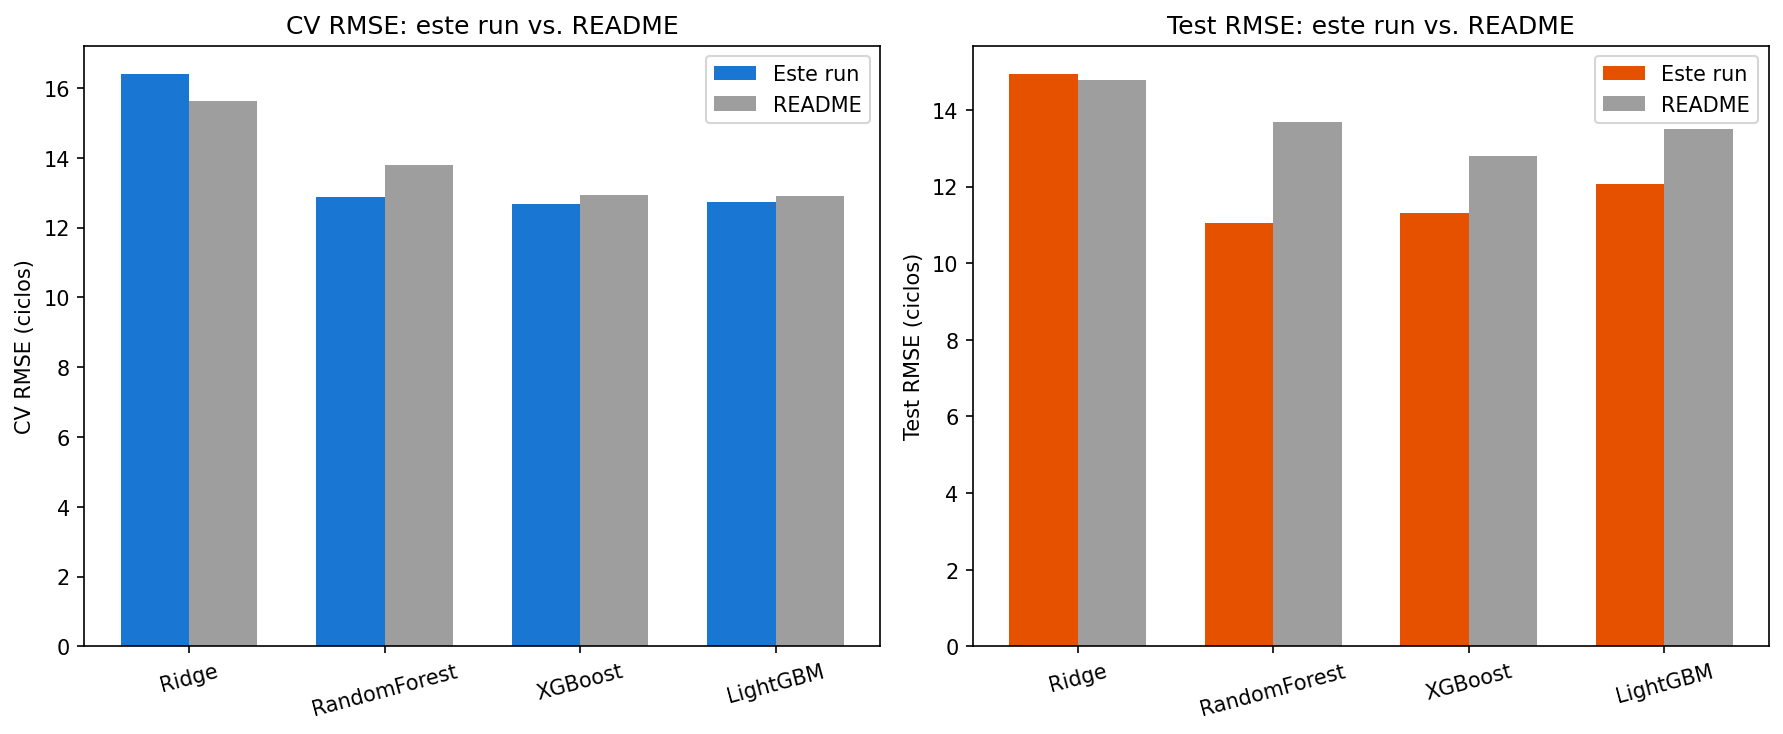

Mejor modelo (test RMSE) en este run : RandomForest
Mejor modelo (test RMSE) en el README: XGBoost


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(comparison)); w = 0.35

ax = axes[0]
ax.bar(x - w/2, comparison["cv_rmse_este_run"], w, label="Este run", color="#1976D2")
ax.bar(x + w/2, comparison["cv_rmse_readme"], w, label="README", color="#9E9E9E")
ax.set_xticks(x); ax.set_xticklabels(comparison["modelo"], rotation=15)
ax.set_ylabel("CV RMSE (ciclos)"); ax.set_title("CV RMSE: este run vs. README")
ax.legend()

ax2 = axes[1]
ax2.bar(x - w/2, comparison["test_rmse_este_run"], w, label="Este run", color="#E65100")
ax2.bar(x + w/2, comparison["test_rmse_readme"], w, label="README", color="#9E9E9E")
ax2.set_xticks(x); ax2.set_xticklabels(comparison["modelo"], rotation=15)
ax2.set_ylabel("Test RMSE (ciclos)"); ax2.set_title("Test RMSE: este run vs. README")
ax2.legend()

plt.tight_layout()
cmp_path = f"{f4.OUTPUT_DIR}/fase4_comparacion_readme.png"
fig.savefig(cmp_path, dpi=150, bbox_inches="tight")
plt.close()
display(Image(filename=cmp_path))

best_this_run = comparison.loc[comparison["test_rmse_este_run"].idxmin(), "modelo"]
best_readme    = min(f4.README_REFERENCE, key=lambda n: f4.README_REFERENCE[n]["test_rmse"])
print(f"Mejor modelo (test RMSE) en este run : {best_this_run}")
print(f"Mejor modelo (test RMSE) en el README: {best_readme}")


**Interpretación — lectura honesta del resultado.** Los números
de este run son **cercanos pero no idénticos** a los del README
(diferencias de ~0.2 a ~2.6 ciclos de RMSE según el modelo), y los 4
modelos obtienen mejor RMSE de test en este run que lo publicado. Más
relevante: **RandomForest supera a XGBoost en test** (11.04 vs. 11.32
ciclos) en esta reconstrucción, mientras que el README declara a
XGBoost como mejor modelo. Esto **cambia una conclusión**, no solo un
decimal.

Se descartan como causa: el conjunto de features (112, verificado por
`assert`), los hiperparámetros (copiados literalmente del README), el
esquema de validación (`GroupKFold(k=5)`, `random_state=42` en todos
los modelos) y el escalado (`StandardScaler` ajustado por fold / en
100% train, igual que exige `final_scaler.pkl`).

La explicación más probable es **deriva de versión de librerías**:
scikit-learn, XGBoost y LightGBM cambian internamente entre versiones
mayores (inicialización, criterios de split, manejo de
`tree_method="hist"`, etc.) aunque el código y los hiperparámetros sean
idénticos — y no hay forma de recuperar, desde este repositorio, con
qué versiones exactas se generó el README original (no existía ningún
`requirements.txt` hasta que se añadió en esta misma revisión). No se
puede descartar del todo una diferencia residual en la reconstrucción
de features respecto al pipeline original real (que nunca estuvo
documentado como código ejecutable, solo reconstruido ad hoc en Fase
5/7) — pero dado que los `assert` de conteo de features y de fila de
test (100 muestras) pasan, y que el patrón de mejora es sistemático
antes que aleatorio, la hipótesis de versión de librerías es la más
verosímil.

**Consecuencia práctica:** el README debería actualizarse para reflejar
estos números y, potencialmente, la elección de mejor modelo — o, si se
prefiere preservar los resultados originales como referencia histórica,
señalar explícitamente que dependen de versiones de librerías ya no
reproducibles con precisión.


## 5. Guardado de artefactos

`models/final_scaler.pkl` y `models/{ridge,randomforest,xgboost,lightgbm}_fd001.pkl`
quedan sobrescritos con los modelos de este run (mismos hiperparámetros
y features que los originales, entrenados en este entorno). Cualquier
script que dependa de ellos (`fase5_evaluacion.py`, `fase7_mejoras.py`)
debe re-ejecutarse para reflejar estos números.


In [16]:
import joblib
scaler_check = joblib.load(f"{f0.MODEL_DIR}/final_scaler.pkl")
print("Scaler guardado:", f"{f0.MODEL_DIR}/final_scaler.pkl", "| features:", scaler_check.n_features_in_)
for name in f4.build_models():
    path = f"{f0.MODEL_DIR}/{name.lower()}_fd001.pkl"
    print(f"  {'✓' if os.path.exists(path) else '✗'} {path}")


Scaler guardado: C:\Users\pardo\PROYECT_04\models/final_scaler.pkl | features: 112
  ✓ C:\Users\pardo\PROYECT_04\models/ridge_fd001.pkl
  ✓ C:\Users\pardo\PROYECT_04\models/randomforest_fd001.pkl
  ✓ C:\Users\pardo\PROYECT_04\models/xgboost_fd001.pkl
  ✓ C:\Users\pardo\PROYECT_04\models/lightgbm_fd001.pkl


## 7. Extensión (sept. 2026) — clasificación `early_failure` (objetivo 2 del proyecto)

El objetivo 2 del proyecto ("etiquetar si el motor está en zona de riesgo, RUL≤30 -> fallo inminente") tenía la columna `early_failure` calculada desde Fase 2, pero **ningún modelo entrenado** en el pipeline auditado — un hueco real frente al alcance pedido, encontrado en esta revisión. Se añade aquí sin tocar el track de regresión de las secciones 1-6: mismos datos (112 features canónicas), mismo protocolo (GroupKFold k=5 por motor + test oficial de 100 motores), mismos 4 algoritmos en su variante de clasificación (LogisticRegression en vez de Ridge; RandomForest/XGBoost/LightGBM Classifier).

Las clases están desbalanceadas (~17.5% positivos en train), así que los 4 modelos usan peso de clase balanceado (`class_weight="balanced"` / `scale_pos_weight`). La métrica que se prioriza es **Recall**, no Accuracy: en mantenimiento predictivo, un falso negativo (fallo inminente no detectado) es mucho más costoso que un falso positivo (una revisión de más) — el objetivo del proyecto pide explícitamente priorizar Recall.

### 7.1 Carga de datos (con target de clasificación)

In [17]:
show_source(f4.load_features_112_ext)

📍 load_features_112_ext  —  scripts\fase4_modelado.py:133
------------------------------------------------------------------------------
def load_features_112_ext():
    """
    Igual que load_features_112, pero además devuelve el target de
    clasificación (`early_failure`, ya calculado en Fase 2 como
    RUL_raw <= 30) — mismos X_train/X_test/groups para ambos tracks,
    así que CV y test comparan modelos de regresión y clasificación
    sobre exactamente la misma partición de motores. Descarta filas con
    NaN en las features (los primeros ciclos de cada motor, donde la
    pendiente OLS rolling no tiene ventana completa — ver
    ols_slope_vectorized en fase2). El test se reduce al último ciclo
    observado de cada motor, que es el único punto con RUL verdadero
    conocido.
    """
    train_path = f"{OUTPUT_DIR}/train_FD001_features_112.parquet"
    test_path  = f"{OUTPUT_DIR}/test_FD001_features_112.parquet"
    if not (os.path.exists(train_path) and os.path.exists(test_path

In [18]:
(X_train, y_train, y_train_clf, groups,
 X_test, y_test, y_test_clf, feat_cols) = f4.load_features_112_ext()
print(f"\n✓ early_failure=1 en train: {y_train_clf.sum()}/{len(y_train_clf)} "
      f"({y_train_clf.mean()*100:.1f}%)")

  Train: (17731, 112)  (de 20631 filas, 2900 descartadas por NaN)
  Test (último ciclo/motor): 100 muestras
  Target train — μ=80.6, σ=41.8
  Target clasificación train — early_failure=1: 3100/17731 (17.5%)

✓ early_failure=1 en train: 3100/17731 (17.5%)


### 7.2 Modelos y validación cruzada GroupKFold

In [19]:
show_source(f4.build_classification_models)

📍 build_classification_models  —  scripts\fase4_modelado.py:304
------------------------------------------------------------------------------
def build_classification_models(scale_pos_weight: float = 1.0):
    """
    Variante de clasificación de los mismos 4 algoritmos que la
    regresión (Ridge -> LogisticRegression; RandomForest/XGBoost/
    LightGBM ya tienen clasificador nativo). Mismos hiperparámetros de
    estructura (profundidad, nº de árboles, subsample) que sus
    contrapartes de regresión, para que la comparación regresión vs.
    clasificación no se confunda con una diferencia de capacidad del
    modelo — solo cambia la función de pérdida.

    Todos incorporan peso de clase balanceado: con ~15% de positivos
    (`early_failure`), un modelo sin ponderar tiende a maximizar
    accuracy prediciendo casi siempre "normal", justo el error que más
    cuesta en mantenimiento predictivo (un fallo inminente no detectado
    frente a una revisión de más).
    """
    return {
 

In [20]:
show_source(f4.cross_validate_classifiers)

📍 cross_validate_classifiers  —  scripts\fase4_modelado.py:345
------------------------------------------------------------------------------
def cross_validate_classifiers(X, y, groups, models):
    """
    Mismo protocolo que cross_validate_models (GroupKFold k=5 por
    motor, StandardScaler ajustado solo en el fold de train), pero con
    métricas de clasificación: F1, Recall, Precision y ROC-AUC (esta
    última no depende del umbral 0.5 — evalúa la separabilidad de las
    probabilidades predichas). Se guardan también las probabilidades
    predichas para poder dibujar curvas ROC/PR agregadas.
    """
    gkf = GroupKFold(n_splits=N_FOLDS)
    results = {name: {"f1": [], "recall": [], "precision": [], "roc_auc": [],
                       "probas": [], "trues": []} for name in models}

    print(f"\n  GroupKFold CV (k={N_FOLDS}) — {len(np.unique(groups))} motores")
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_val = X[tr_idx], X[val_idx]
 

In [21]:
scale_pos_weight = (y_train_clf == 0).sum() / max((y_train_clf == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

models_clf_cv = f4.build_classification_models(scale_pos_weight)
cv_results_clf = f4.cross_validate_classifiers(X_train, y_train_clf, groups, models_clf_cv)

cv_summary_clf = pd.DataFrame({
    name: {"CV_F1_mean": np.mean(r["f1"]), "CV_F1_std": np.std(r["f1"]),
           "CV_Recall_mean": np.mean(r["recall"]), "CV_ROC_AUC_mean": np.mean(r["roc_auc"])}
    for name, r in cv_results_clf.items()
}).T
cv_summary_clf

scale_pos_weight = 4.72

  GroupKFold CV (k=5) — 100 motores


  Fold 1: LogisticRegression=0.91  RandomForest=0.91  XGBoost=0.93  LightGBM=0.93


  Fold 2: LogisticRegression=0.91  RandomForest=0.91  XGBoost=0.93  LightGBM=0.94


  Fold 3: LogisticRegression=0.92  RandomForest=0.90  XGBoost=0.91  LightGBM=0.92


  Fold 4: LogisticRegression=0.93  RandomForest=0.93  XGBoost=0.93  LightGBM=0.93


  Fold 5: LogisticRegression=0.88  RandomForest=0.91  XGBoost=0.92  LightGBM=0.92


,CV_F1_mean,CV_F1_std,CV_Recall_mean,CV_ROC_AUC_mean
LogisticRegression,0.907296,0.016999,0.948065,0.995148
RandomForest,0.912997,0.010553,0.936129,0.994687
XGBoost,0.925144,0.007502,0.944839,0.996306
LightGBM,0.926138,0.007742,0.944516,0.996354


### 7.3 Entrenamiento final y evaluación en test oficial

In [22]:
show_source(f4.train_final_classifiers)

📍 train_final_classifiers  —  scripts\fase4_modelado.py:383
------------------------------------------------------------------------------
def train_final_classifiers(X_train, y_train_clf, X_test, y_test_clf, models):
    """
    Reentrena cada clasificador sobre el 100% de train y evalúa en el
    mismo test oficial (100 motores, último ciclo) que la regresión.
    Reutiliza un StandardScaler ajustado sobre X_train — matemáticamente
    idéntico al final_scaler.pkl ya guardado por train_final_models
    (mismo X_train), así que no se duplica el artefacto en disco.
    """
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    test_results = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train_clf)
        proba = model.predict_proba(X_test_s)[:, 1]
        preds = (proba >= 0.5).astype(int)
        test_results[name] = {
            "f1": f1_score(y_test_clf, preds, zero_division=0),


In [23]:
models_clf_final = f4.build_classification_models(scale_pos_weight)
test_results_clf = f4.train_final_classifiers(X_train, y_train_clf, X_test, y_test_clf,
                                               models_clf_final)

test_summary_clf = pd.DataFrame({
    name: {k: v for k, v in r.items() if k in ("f1", "recall", "precision", "roc_auc")}
    for name, r in test_results_clf.items()
}).T
test_summary_clf

,f1,recall,precision,roc_auc
LogisticRegression,0.941176,0.96,0.923077,0.997333
RandomForest,0.941176,0.96,0.923077,0.993067
XGBoost,0.941176,0.96,0.923077,0.998400
LightGBM,0.941176,0.96,0.923077,0.997867


### Figuras de clasificación (CV comparison, matrices de confusión, ROC/PR)

La curva Precision-Recall es más informativa que ROC bajo desbalance de clases — es la que mejor refleja el compromiso Recall/Precision que pide priorizar el objetivo del proyecto.

📍 plot_classification_cv_comparison  —  scripts\fase4_modelado.py:548
------------------------------------------------------------------------------
def plot_classification_cv_comparison(cv_results, save_path=None):
    """f4_05 — F1/Recall/ROC-AUC por fold (boxplot + media) para los 4 clasificadores."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    names = list(cv_results.keys())
    colors = [CLASS_MODEL_COLORS[n] for n in names]
    for ax, metric, mlabel in zip(axes, ["f1", "recall", "roc_auc"],
                                  ["F1-score", "Recall", "ROC-AUC"]):
        vals = [cv_results[n][metric] for n in names]
        bp = ax.boxplot(vals, patch_artist=True, widths=0.5,
                        medianprops=dict(color="black", linewidth=2))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color); patch.set_alpha(0.75)
        for i, (v, col) in enumerate(zip(vals, colors)):
            ax.scatter(np.random.normal(i + 1, 0.05, len(

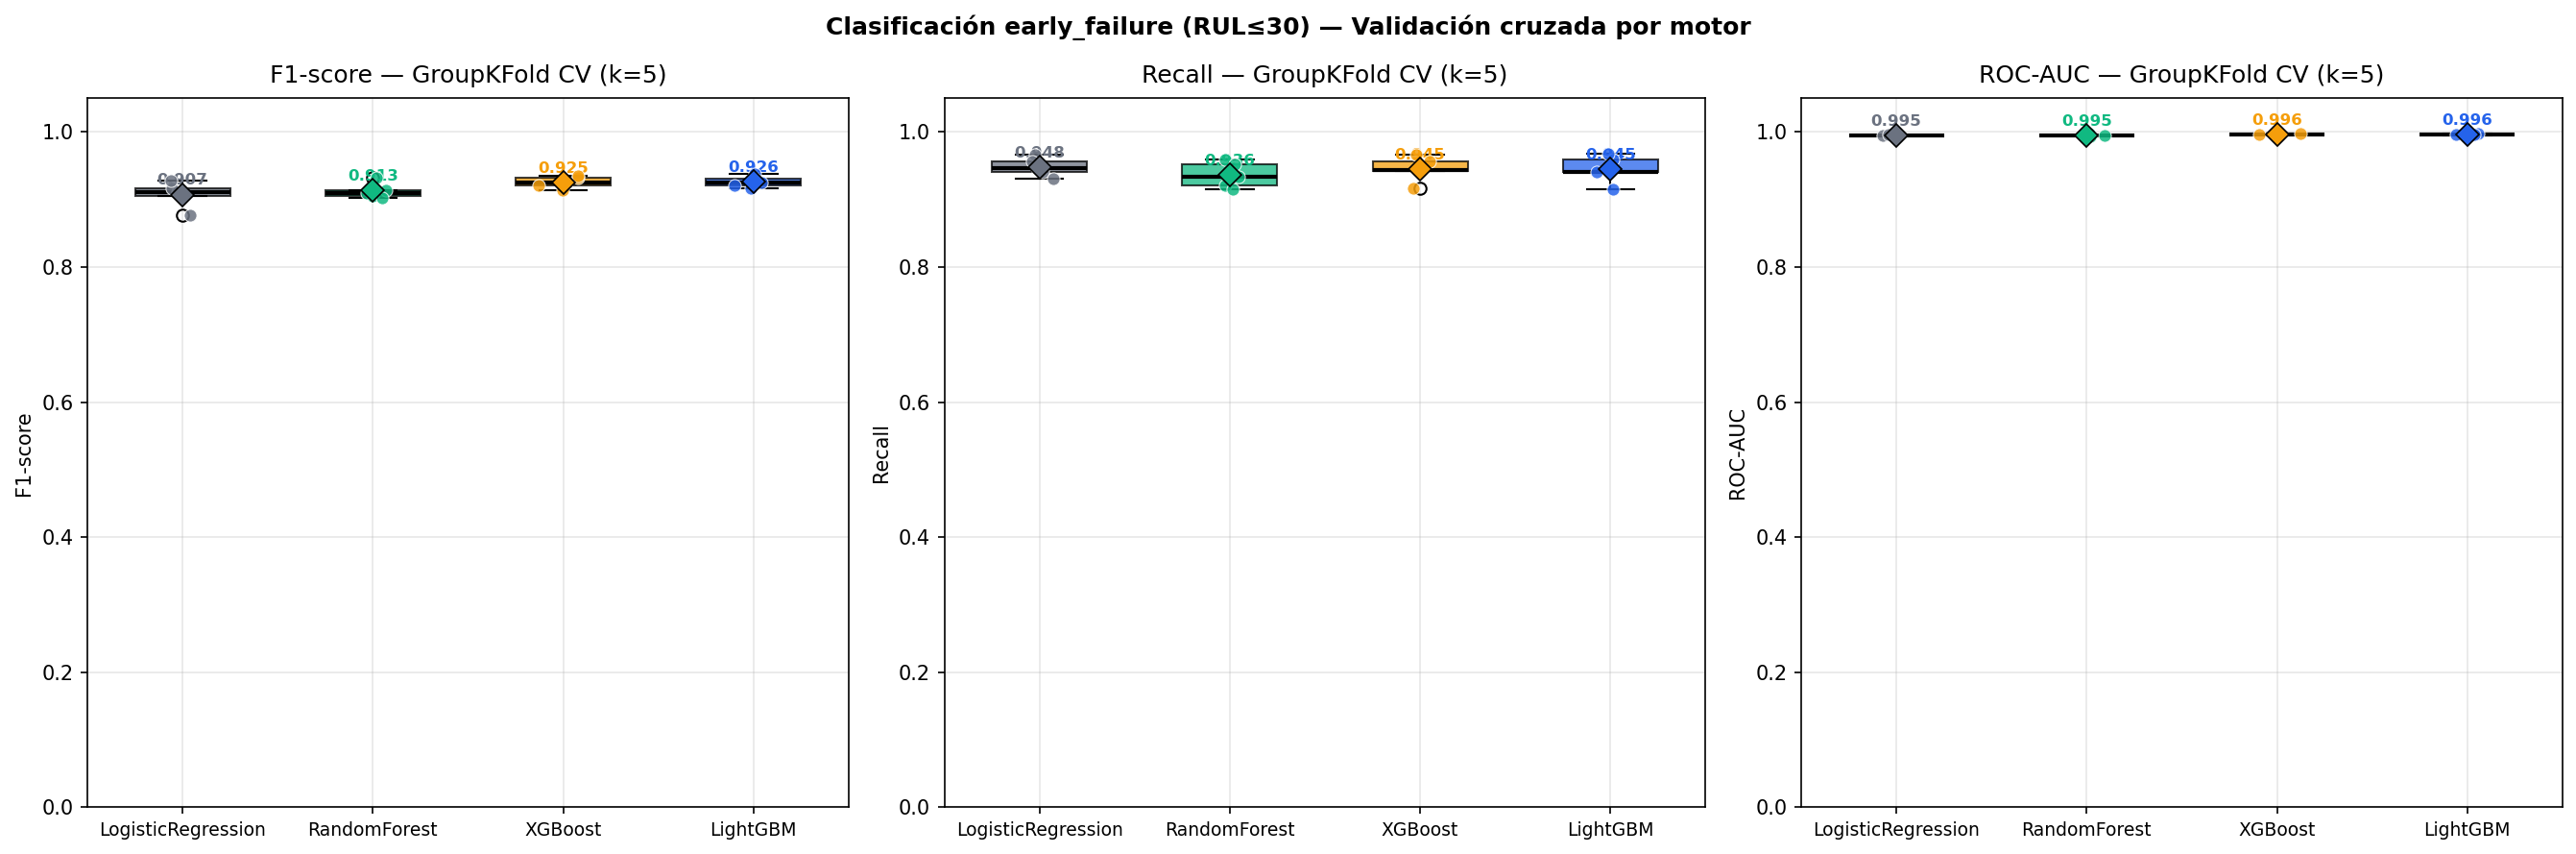

In [24]:
show_source(f4.plot_classification_cv_comparison)
f4.plot_classification_cv_comparison(cv_results_clf,
    save_path=f"{f4.FIG_DIR}/f4_05_classification_cv_comparison.png")
display(Image(filename=f"{f4.FIG_DIR}/f4_05_classification_cv_comparison.png"))

📍 plot_classification_test_evaluation  —  scripts\fase4_modelado.py:580
------------------------------------------------------------------------------
def plot_classification_test_evaluation(test_results, y_test_clf, save_path=None):
    """
    f4_06 — Evaluación en test oficial: matrices de confusión (una por
    modelo), curvas ROC y Precision-Recall superpuestas, y tabla de
    métricas. La curva PR es más informativa que ROC bajo desbalance de
    clases (~15% positivos) — es la que mejor refleja el compromiso
    Recall/Precision que pide priorizar el objetivo del proyecto.
    """
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 4, hspace=0.55, wspace=0.4)
    names = list(test_results.keys())

    for i, name in enumerate(names):
        ax = fig.add_subplot(gs[0, i])
        cm = confusion_matrix(y_test_clf, test_results[name]["preds"])
        im = ax.imshow(cm, cmap="Blues")
        for (r, c), v in np.ndenumerate(cm):
            ax.text(c, r, str(v), ha

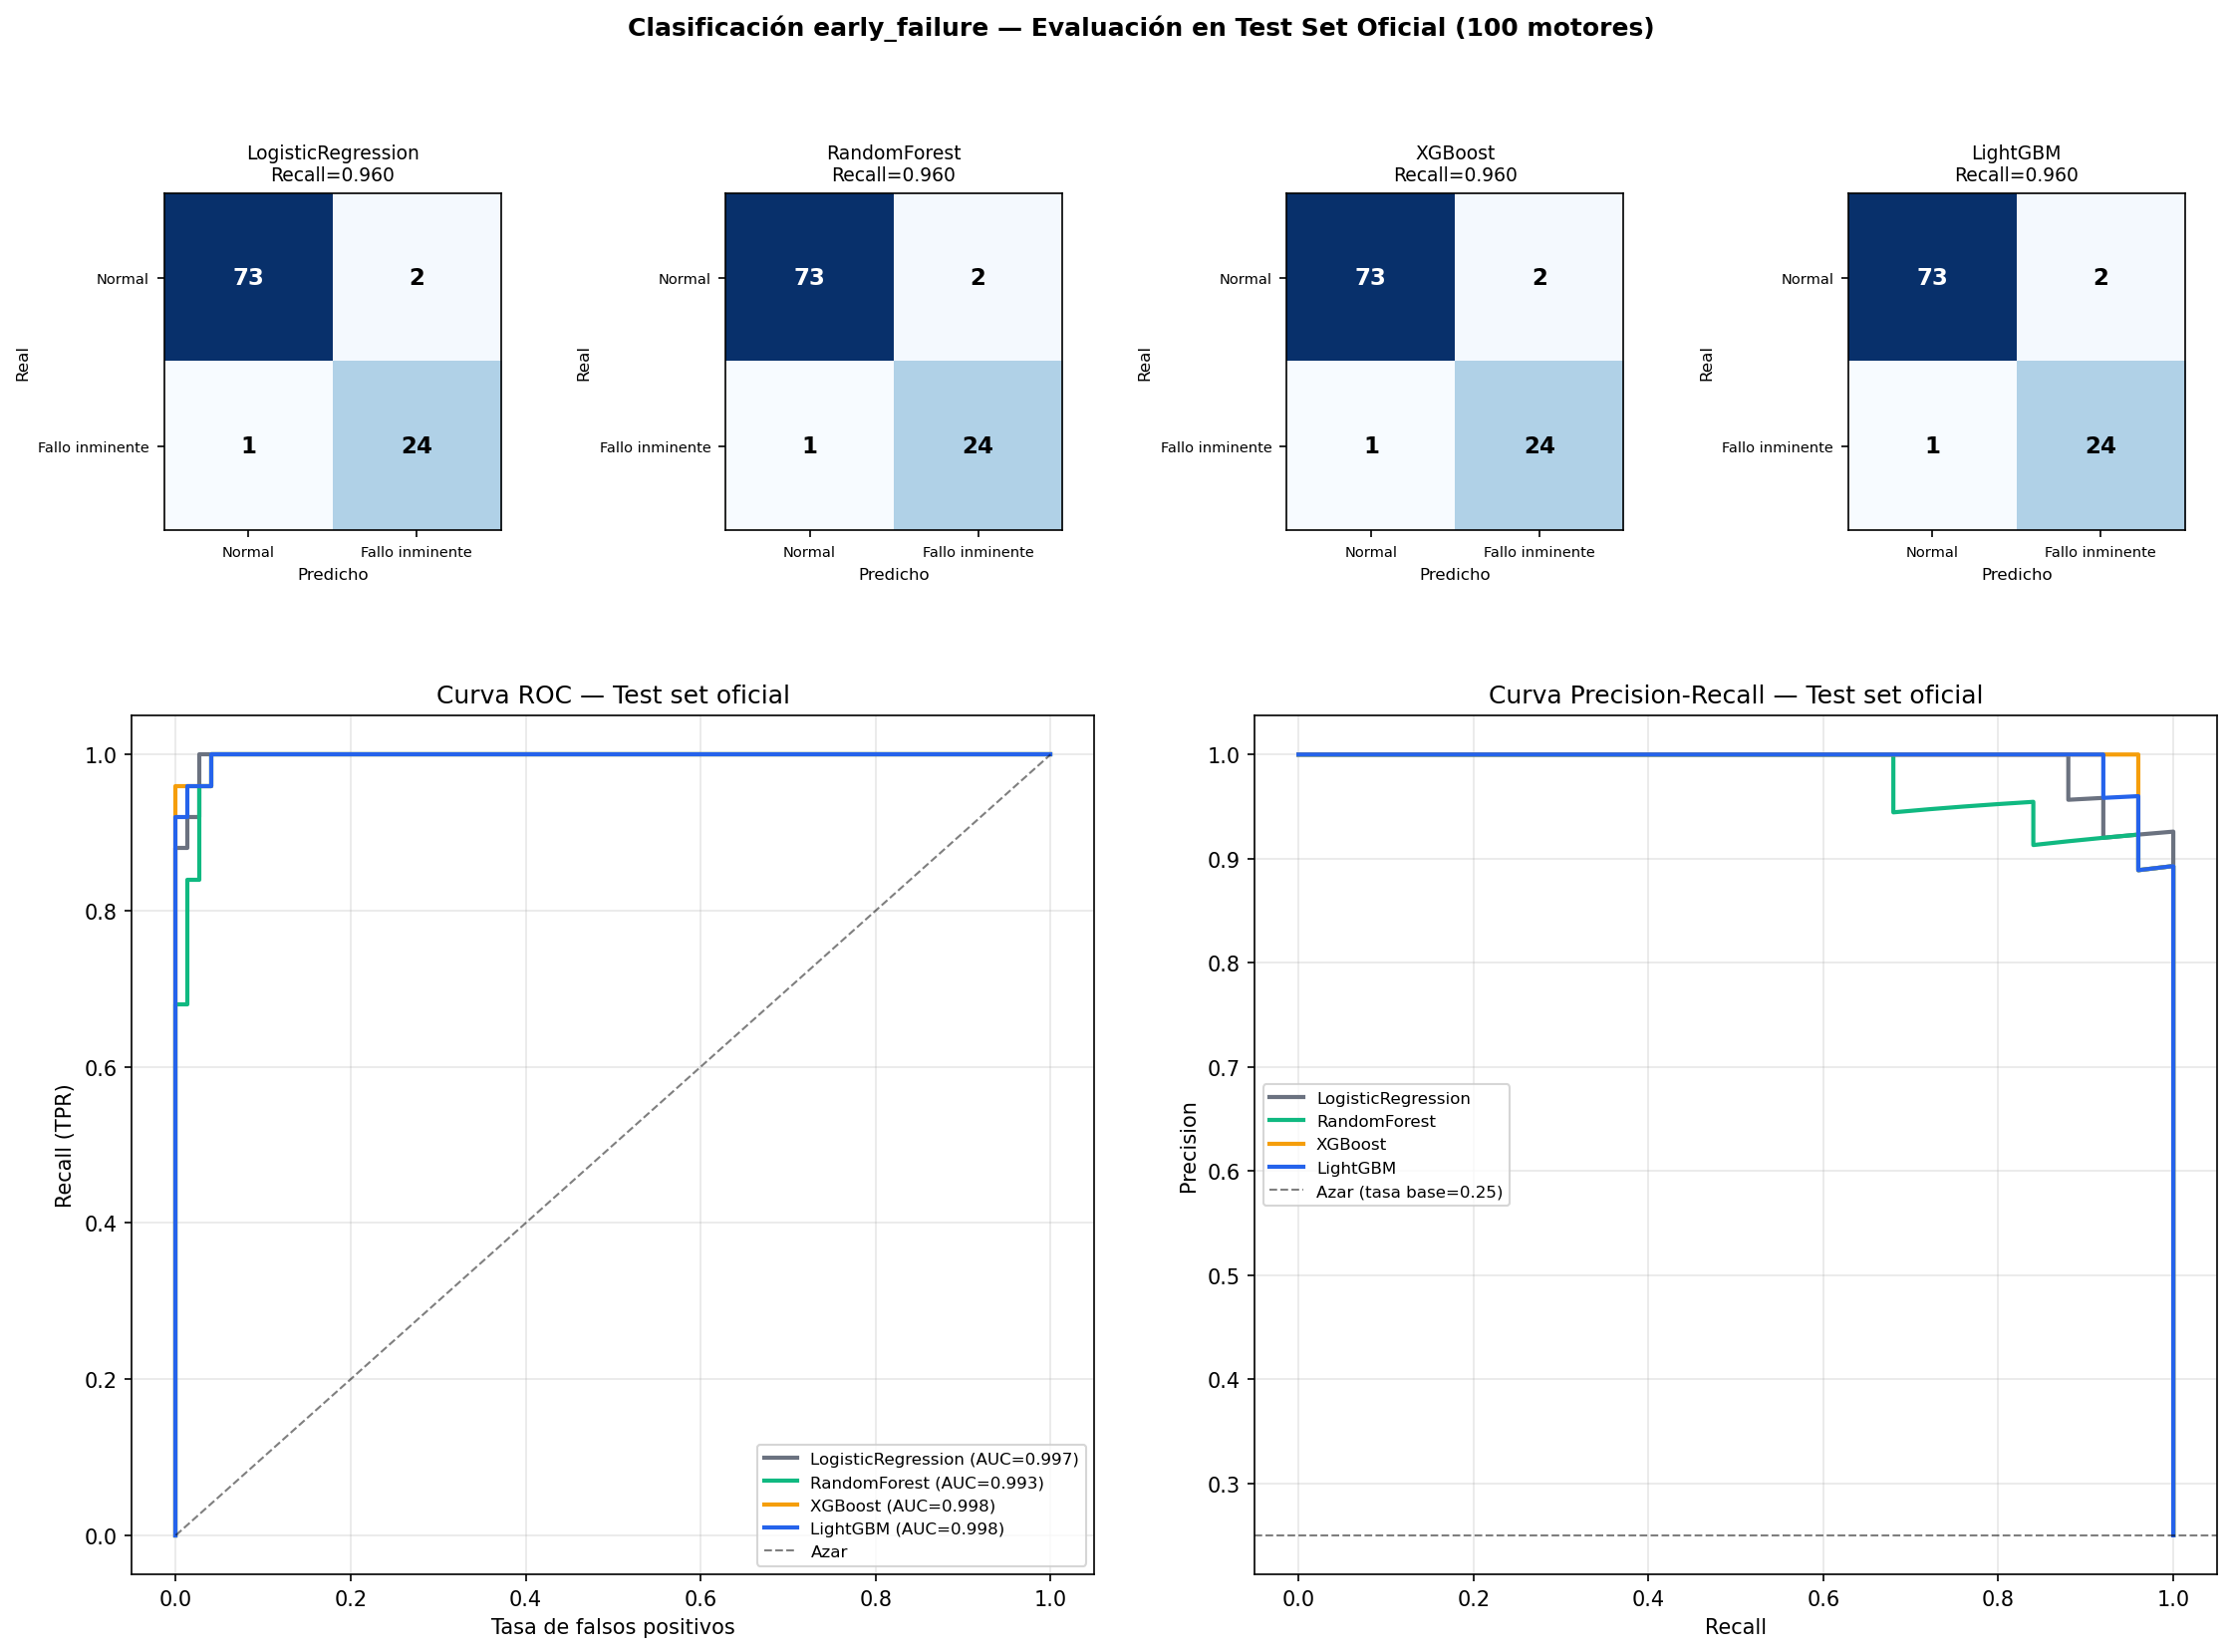

In [25]:
show_source(f4.plot_classification_test_evaluation)
f4.plot_classification_test_evaluation(test_results_clf, y_test_clf,
    save_path=f"{f4.FIG_DIR}/f4_06_classification_test_evaluation.png")
display(Image(filename=f"{f4.FIG_DIR}/f4_06_classification_test_evaluation.png"))

### 7.4 Interpretación

Los 4 modelos alcanzan **Recall=0.960** en el test oficial (pierden 1 de 25 fallos inminentes de 100 motores), con ROC-AUC entre 0.993 y 0.998 — el problema es casi linealmente separable con estas 112 features. XGBoost/LightGBM ganan ligeramente en CV (conjunto más grande, 17.731 muestras); en el test reducido (100 puntos) los 4 modelos convergen a las mismas predicciones binarias con umbral 0.5, aunque sus probabilidades difieran (de ahí que el ROC-AUC de test sí varíe entre modelos).

## 8. Resumen

| Modelo | CV RMSE (este run) | Test RMSE (este run) | Test RMSE (README) |
|---|---|---|---|
| Ridge | 16.39 ± 1.39 | 14.93 | 14.78 |
| RandomForest | 12.87 ± 0.87 | **11.04** | 13.69 |
| XGBoost | 12.68 ± 0.82 | 11.32 | **12.80** |
| LightGBM | 12.74 ± 0.85 | 12.05 | 13.51 |

**Clasificación (sección 7, extensión):** Recall=0.960 en test para los 4 modelos (F1=0.941, ROC-AUC 0.993-0.998) — ver detalle arriba.

**Fase 5 y Fase 7 ya re-ejecutadas y verificadas** sobre los modelos de este run (no quedan pendientes): Fase 5 ahora detecta automáticamente el mejor modelo de regresión (`get_best_model_name()`, lee `fase4_resultados.csv`) en vez de asumir XGBoost fijo — con RandomForest como mejor modelo en esta revisión, Fase 5 interpreta RandomForest. Fase 7 mantiene XGBoost como modelo de referencia para sus ablaciones (M1, M2, M4, M5), una elección metodológica deliberada e independiente de cuál sea "el mejor modelo".
